In [3]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# read in dataframe
df = pd.read_csv("final_data.csv", index_col=0)

In [6]:
df.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'change', 'diabetesMed', 'readmitted',
       'num_hospitalizations', 'avg_procedure', 'total_visits',
       'num_med_changes', 'num_med_increase'],
      dtype='str')

In [7]:
df.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_procedures,num_medications,number_outpatient,...,diag_3,number_diagnoses,change,diabetesMed,readmitted,num_hospitalizations,avg_procedure,total_visits,num_med_changes,num_med_increase
1,Caucasian,Female,[10-20),1,1,7,3,0,18,0,...,255,9,1,1,0,1,0.000000,0,1,1
2,AfricanAmerican,Female,[20-30),1,1,7,2,5,13,2,...,V27,6,0,1,0,1,2.500000,3,0,0
3,Caucasian,Male,[30-40),1,1,7,2,1,16,0,...,403,7,1,1,0,1,0.500000,0,1,1
4,Caucasian,Male,[40-50),1,1,7,1,0,8,0,...,250,5,1,1,0,1,0.000000,0,0,0
5,Caucasian,Male,[50-60),2,1,2,3,6,16,0,...,250,9,0,1,0,1,2.000000,0,0,0
6,Caucasian,Male,[60-70),3,1,2,4,1,21,0,...,V45,7,1,1,0,1,0.250000,0,0,0
7,Caucasian,Male,[70-80),1,1,7,5,0,12,0,...,250,8,0,1,0,1,0.000000,0,0,0
8,Caucasian,Female,[80-90),2,1,4,13,2,28,0,...,38,8,1,1,0,1,0.153846,0,0,0
9,Caucasian,Female,[90-100),3,3,4,12,3,18,0,...,486,8,1,1,0,1,0.250000,0,0,0
10,AfricanAmerican,Female,[40-50),1,1,7,9,2,17,0,...,996,9,0,1,0,1,0.222222,0,0,0


In [8]:
%pip install seaborn
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\test\AppData\Local\Temp\ipykernel_28784\2808252853.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='race', order=df['race'].value_counts().index, palette="Set2")


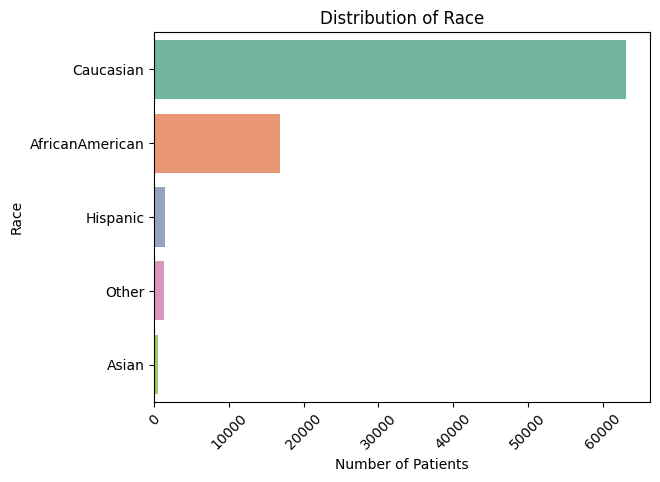

In [9]:
# plot distribution of patient demographics
sns.countplot(data=df, y='race', order=df['race'].value_counts().index, palette="Set2")
plt.ylabel('Race')
plt.xlabel('Number of Patients')
plt.title('Distribution of Race')
plt.xticks(rotation=45)
plt.show()

C:\Users\test\AppData\Local\Temp\ipykernel_28784\4249064908.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age', order=age_order, palette='mako')


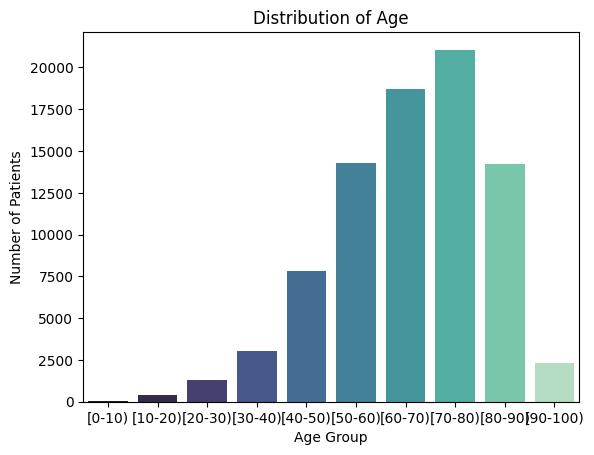

In [10]:
# plot age distribution
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

sns.countplot(data=df, x='age', order=age_order, palette='mako')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.title('Distribution of Age')
plt.show()

C:\Users\test\AppData\Local\Temp\ipykernel_28784\1511386638.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='time_in_hospital', y='age', order=age_order, palette='mako')


Text(0.5, 1.0, 'Hospitalization Length Across Age Groups')

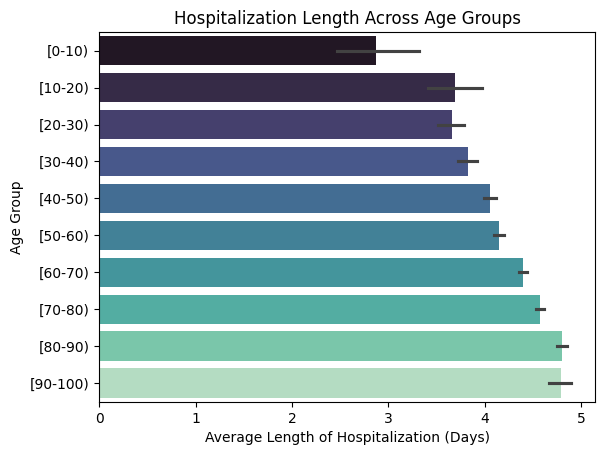

In [11]:
# avg length of stay by age category 
sns.barplot(data=df, x='time_in_hospital', y='age', order=age_order, palette='mako')
plt.xlabel('Average Length of Hospitalization (Days)')
plt.ylabel('Age Group')
plt.title('Hospitalization Length Across Age Groups')

C:\Users\test\AppData\Local\Temp\ipykernel_28784\3061972728.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='time_in_hospital', y='race', order=order, palette='Set2')


Text(0.5, 1.0, 'Hospitalization Length Across Race')

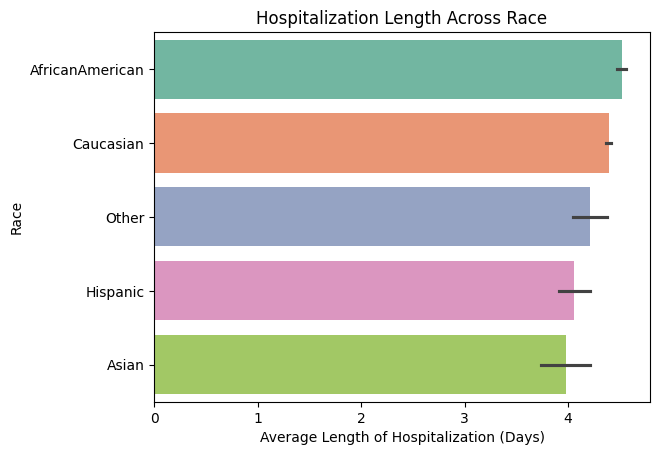

In [12]:
# avg length of stay by race category 


# order by highest to lowest
order = df.groupby('race')['time_in_hospital'].mean().sort_values(ascending=False).index

sns.barplot(data=df, x='time_in_hospital', y='race', order=order, palette='Set2')
plt.xlabel('Average Length of Hospitalization (Days)')
plt.ylabel('Race')
plt.title('Hospitalization Length Across Race')

([<matplotlib.axis.XTick at 0x1d1d4103750>,
 [Text(0, 0, 'Not Readmitted'), Text(1, 0, 'Readmitted')])

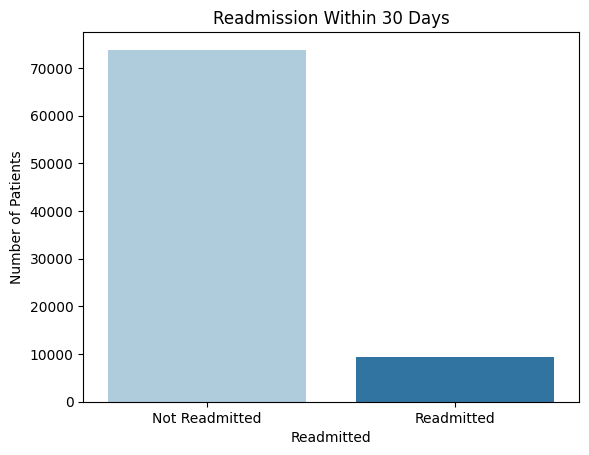

In [13]:
# readmitted vs not readmitted

sns.countplot(data=df, x='readmitted', hue='readmitted', palette='Paired', legend=False)
plt.xlabel('Readmitted')
plt.ylabel('Number of Patients')
plt.title('Readmission Within 30 Days')
plt.xticks(ticks=[0, 1], labels=['Not Readmitted', 'Readmitted'])

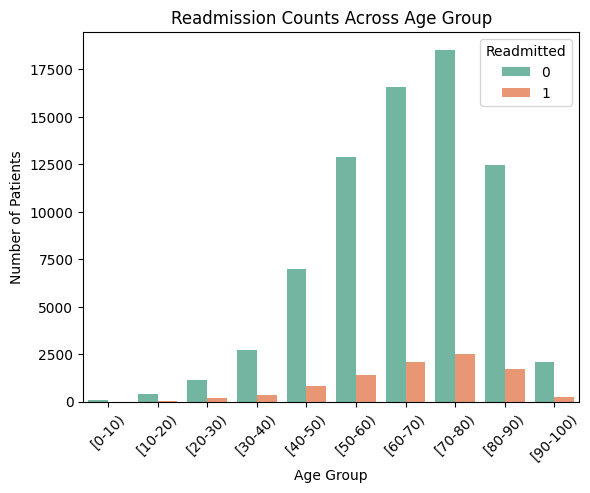

In [ ]:
# plot relationship between age and readmission

sns.countplot(data=df, x='age', hue='readmitted', order=age_order, palette='Set2')

plt.title('Readmission Counts Across Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Readmitted', loc='upper right')
plt.show()

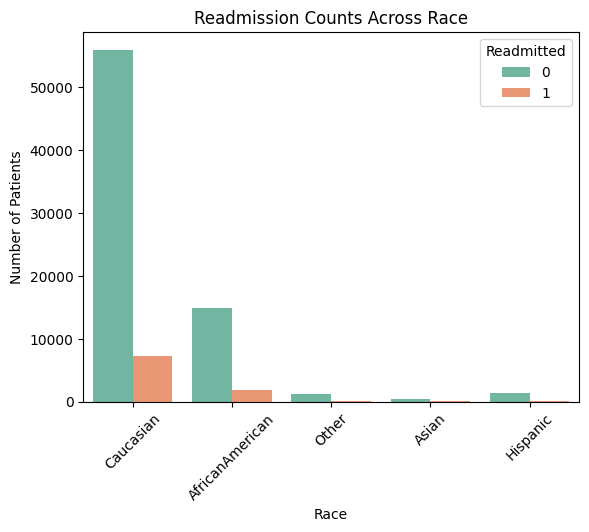

In [ ]:
# plot relationship between race and readmission

sns.countplot(data=df, x='race', hue='readmitted', palette='Set2')

plt.title('Readmission Counts Across Race')
plt.xlabel('Race')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Readmitted', loc='upper right')
plt.show()

In [ ]:
# import icd code information 
icd_code_df = pd.read_csv("icd_code.csv", index_col=0)
icd_code_df.columns

Index(['code', 'description', 'primary_category', 'subcategory'], dtype='str')

In [ ]:
# merge admissions and icd code information
merged = df.merge(icd_code_df,left_on='diag_1', right_on='code')

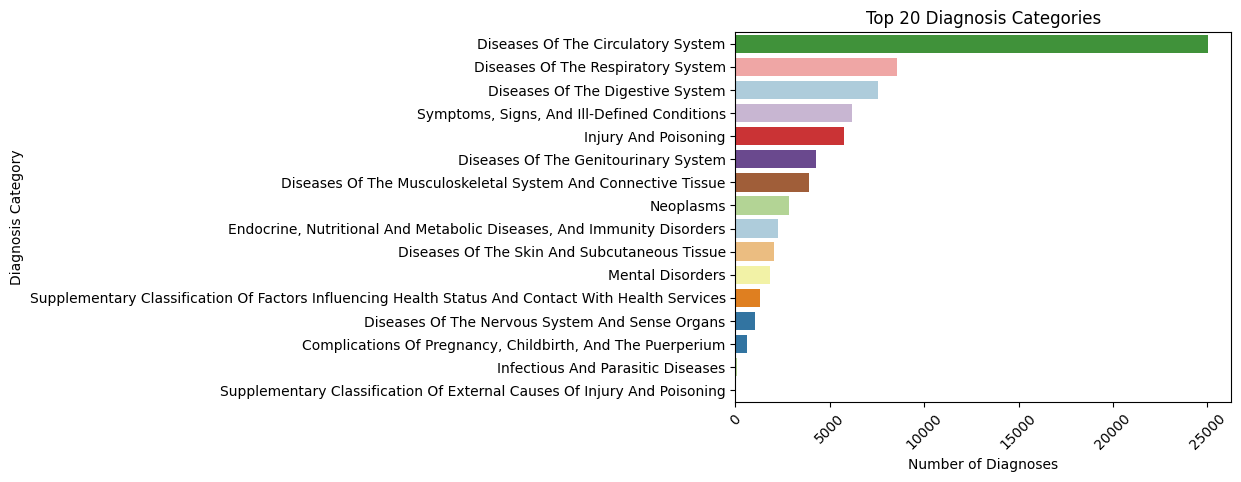

In [ ]:
# most common primary diagnosis 

top_20_diag = merged['primary_category'].value_counts().nlargest(20).index
sns.countplot(data=merged, y='primary_category', hue='primary_category', order=top_20_diag, palette='Paired', legend=False)

plt.title('Top 20 Diagnosis Categories')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Diagnosis Category')
plt.xticks(rotation=45)
plt.show()

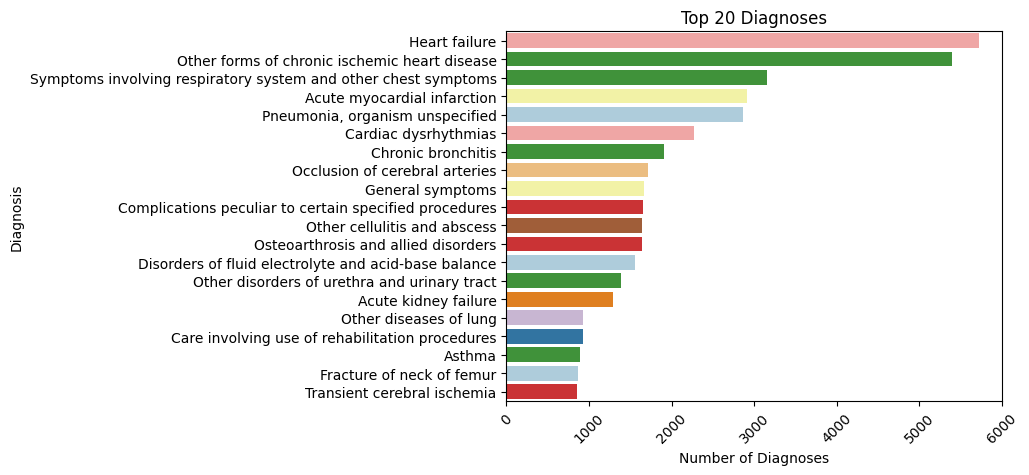

In [ ]:
# plot top primary diagnoses

top_20_diag = merged['description'].value_counts().nlargest(20).index
sns.countplot(data=merged, y='description', hue='description', order=top_20_diag, palette='Paired', legend=False)

plt.title('Top 20 Diagnoses')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Diagnosis')
plt.xticks(rotation=45)
plt.show()